In [11]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.eval.seg_eval import evaluate_metrics

In [13]:
from pathlib import Path

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/kk/masks")
PRED_DIR = Path("../inference/clipseg_cloudsen_zs/masks")
RUN_ROOT = Path("../inference/clipseg_cloudsen_zs")

print("GT_DIR  :", GT_DIR, "exists:", GT_DIR.exists())
print("PRED_DIR:", PRED_DIR, "exists:", PRED_DIR.exists())
print("RUN_ROOT:", RUN_ROOT, "exists:", RUN_ROOT.exists())


GT_DIR  : ../data/cloudsen12plus/export_p509_high_npz/kk/masks exists: True
PRED_DIR: ../inference/clipseg_cloudsen_zs/masks exists: True
RUN_ROOT: ../inference/clipseg_cloudsen_zs exists: True


In [14]:
def peek_npz(dirpath: Path, n=5):
    files = sorted(dirpath.glob("*.npz"))
    print(f"\n{dirpath} (npz={len(files)})")
    for p in files[:n]:
        z = np.load(p)
        print(" ", p.name, "keys:", z.files)

peek_npz(GT_DIR)
peek_npz(PRED_DIR)

gt_stems = {p.stem for p in GT_DIR.glob("*.npz")}
pr_stems = {p.stem for p in PRED_DIR.glob("*.npz")}
common = gt_stems & pr_stems
print(f"\nGT={len(gt_stems)}  Pred={len(pr_stems)}  Matched={len(common)}")
print("Example matches:", sorted(list(common))[:10])


../data/cloudsen12plus/export_p509_high_npz/kk/masks (npz=4)
  ROI_0001__20190212T142031_20190212T143214_T19FDF.npz keys: ['mask']
  ROI_0001__20190304T142031_20190304T142654_T19FDF.npz keys: ['mask']
  ROI_0001__20190316T141049_20190316T142437_T19FDF.npz keys: ['mask']
  ROI_0001__20190525T141059_20190525T142053_T19FDF.npz keys: ['mask']

../inference/clipseg_cloudsen_zs/masks (npz=4)
  ROI_0001__20190212T142031_20190212T143214_T19FDF.npz keys: ['mask']
  ROI_0001__20190304T142031_20190304T142654_T19FDF.npz keys: ['mask']
  ROI_0001__20190316T141049_20190316T142437_T19FDF.npz keys: ['mask']
  ROI_0001__20190525T141059_20190525T142053_T19FDF.npz keys: ['mask']

GT=4  Pred=4  Matched=4
Example matches: ['ROI_0001__20190212T142031_20190212T143214_T19FDF', 'ROI_0001__20190304T142031_20190304T142654_T19FDF', 'ROI_0001__20190316T141049_20190316T142437_T19FDF', 'ROI_0001__20190525T141059_20190525T142053_T19FDF']


In [15]:
NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

result = evaluate_metrics(
    gt_dir=GT_DIR,
    pred_dir=PRED_DIR,
    model="clipseg",
    dataset="cloudsen12plus",
    stage="kk_eval",
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    run_root=RUN_ROOT,
    gt_key="mask",
    pred_key="mask",
    gt_ext=".npz",
    pred_ext=".npz",
    ignore_index=None,
    strict=True,
)

result

{'miou_csv': '../inference/clipseg_cloudsen_zs/miou_clipseg_cloudsen12plus_kk_eval.csv',
 'cm_csv': '../inference/clipseg_cloudsen_zs/cm_clipseg_cloudsen12plus_kk_eval.csv',
 'num_samples': 4,
 'aggregate_miou': 0.21256285392454982,
 'aggregate_pixel_acc': 0.3637237548828125}

In [18]:
miou_df = pd.read_csv(result["miou_csv"])
cm_df   = pd.read_csv(result["cm_csv"])

display(miou_df.head())


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,ROI_0001__20190212T142031_20190212T143214_T19FDF,0.171916,0.539494,0.480186,0.000000,0.207477,0.000000
1,ROI_0001__20190304T142031_20190304T142654_T19FDF,0.136889,0.121922,0.033840,0.494157,0.000044,0.019515
2,ROI_0001__20190316T141049_20190316T142437_T19FDF,0.234316,0.486916,0.466624,0.362205,0.000000,0.108437
3,ROI_0001__20190525T141059_20190525T142053_T19FDF,0.182415,0.306564,0.203580,0.195937,0.157843,0.172300
4,__aggregate__,0.212563,0.363724,0.291934,0.337353,0.156486,0.064479


In [26]:
import numpy as np
import pandas as pd
from pathlib import Path


NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

def confusion_matrix_np(gt: np.ndarray, pred: np.ndarray, num_classes: int) -> np.ndarray:
    keep = (gt >= 0) & (gt < num_classes) & (pred >= 0) & (pred < num_classes)
    gt = gt[keep].astype(np.int64)
    pred = pred[keep].astype(np.int64)

    k = gt * num_classes + pred
    cm = np.bincount(k, minlength=num_classes * num_classes).reshape(num_classes, num_classes)
    return cm.astype(np.int64)

gt_map = {p.stem: p for p in GT_DIR.glob("*.npz")}
pr_map = {p.stem: p for p in PRED_DIR.glob("*.npz")}
common = sorted(set(gt_map) & set(pr_map))

print(f"Matched pairs: {len(common)}")

START = 0
MAX_SHOW = 4
PAUSE = True
SHOW_PIXEL_STATS = True

for i, stem in enumerate(common[START:START+MAX_SHOW], start=START):
    gt = np.load(gt_map[stem])["mask"].astype(np.int64)
    pr = np.load(pr_map[stem])["mask"].astype(np.int64)

    if gt.shape != pr.shape:
        print(f"\n[{i}] {stem}  SHAPE MISMATCH: gt={gt.shape}, pred={pr.shape}")
        continue

    cm = confusion_matrix_np(gt, pr, NUM_CLASSES)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{n}" for n in CLASS_NAMES],
        columns=[f"pred_{n}" for n in CLASS_NAMES],
    )

    print(f"\n[{i}] {stem}")
    display(cm_df)

    if SHOW_PIXEL_STATS:
        total = cm.sum()
        correct = np.trace(cm)
        acc = (correct / total) if total > 0 else 0.0
        print(f"pixels={total:,}  correct={correct:,}  pixel_acc={acc:.4f}")

    if PAUSE:
        input("Press Enter for next image...")

Matched pairs: 4

[0] ROI_0001__20190212T142031_20190212T143214_T19FDF


,pred_clear,pred_thick_cloud,pred_thin_cloud,pred_cloud_shadow
true_clear,110775,0,65575,3642
true_thick_cloud,0,0,0,0
true_thin_cloud,50700,208,30650,594
true_cloud_shadow,0,0,0,0


pixels=262,144  correct=141,425  pixel_acc=0.5395

[1] ROI_0001__20190304T142031_20190304T142654_T19FDF


,pred_clear,pred_thick_cloud,pred_thin_cloud,pred_cloud_shadow
true_clear,7309,1092,3207,1228
true_thick_cloud,10428,20509,7348,1416
true_thin_cloud,0,0,1,0
true_cloud_shadow,192721,710,12033,4142


pixels=262,144  correct=31,961  pixel_acc=0.1219

[2] ROI_0001__20190316T141049_20190316T142437_T19FDF


,pred_clear,pred_thick_cloud,pred_thin_cloud,pred_cloud_shadow
true_clear,68037,210,1852,7691
true_thick_cloud,33590,50433,23438,31462
true_thin_cloud,0,0,0,0
true_cloud_shadow,34427,106,1726,9172


pixels=262,144  correct=127,642  pixel_acc=0.4869

[3] ROI_0001__20190525T141059_20190525T142053_T19FDF


,pred_clear,pred_thick_cloud,pred_thin_cloud,pred_cloud_shadow
true_clear,30311,1858,69315,10367
true_thick_cloud,15614,13714,26789,8863
true_thin_cloud,18232,3154,26593,10618
true_cloud_shadow,3193,0,13777,9746


pixels=262,144  correct=80,364  pixel_acc=0.3066


Images: 4 | GT: 4 | Pred: 4 | Matched: 4


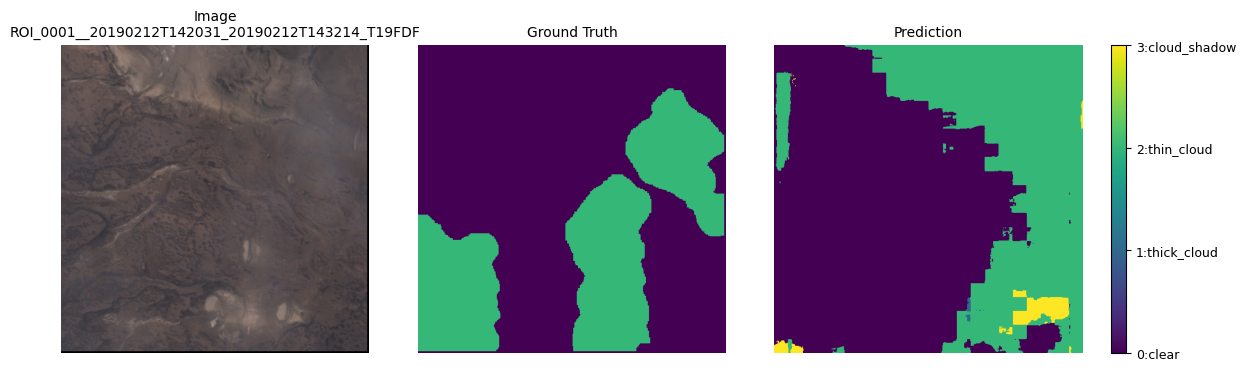

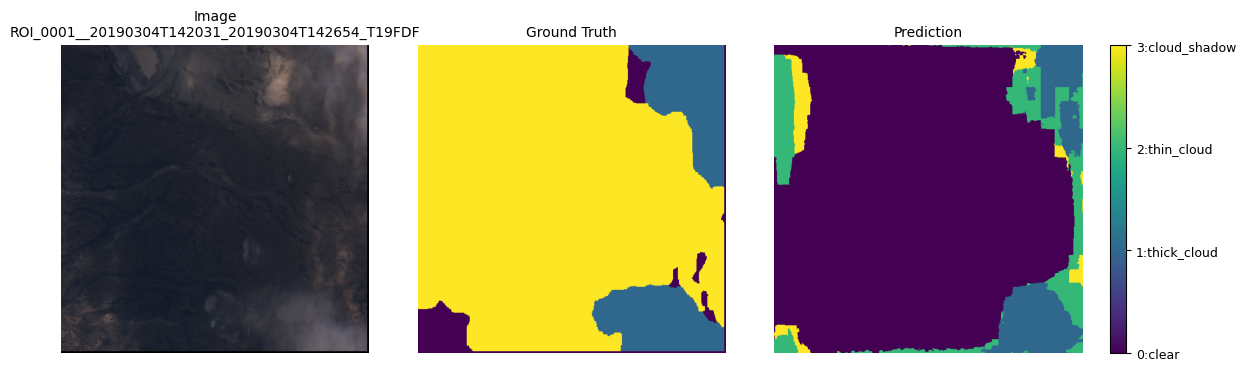

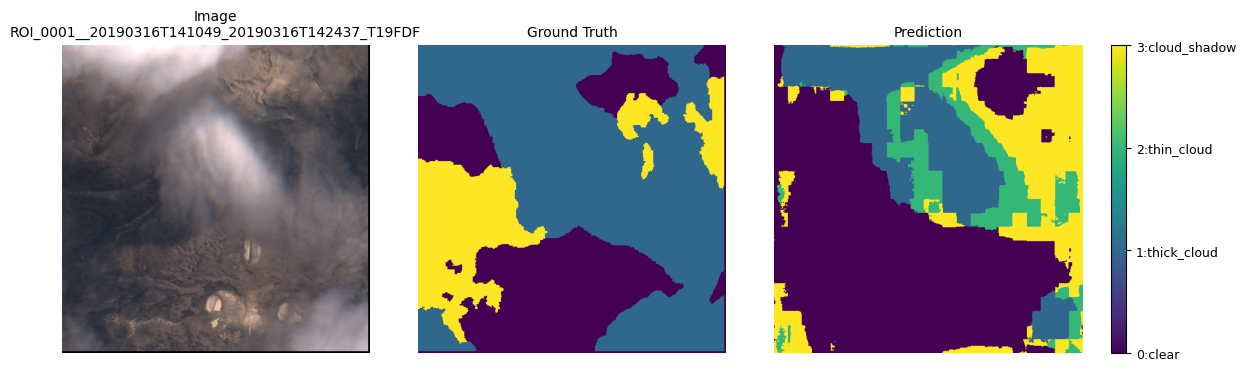

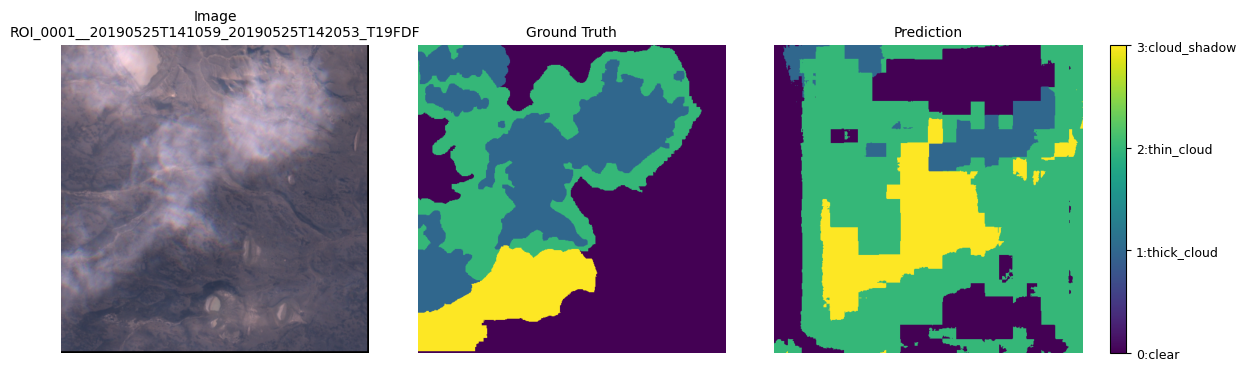

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMG_DIR  = Path("../data/cloudsen12plus/export_p509_high_npz/kk")

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

def load_rgb_from_npz(p: Path) -> np.ndarray:
    """Return HxWx3 uint8 RGB for plotting."""
    with np.load(p) as z:
        if "image" not in z.files:
            raise KeyError(f"{p.name}: expected key 'image', found {z.files}")
        arr = z["image"]
    if arr.ndim != 3 or arr.shape[0] != 3:
        raise ValueError(f"{p.name}: expected (3,H,W), got {arr.shape}")
    hwc = np.transpose(arr, (1,2,0))
    hwc = np.clip(hwc, 0.0, 1.0)
    return (hwc * 255.0).round().astype(np.uint8)

def load_mask_from_npz(p: Path) -> np.ndarray:
    with np.load(p) as z:
        if "mask" not in z.files:
            raise KeyError(f"{p.name}: expected key 'mask', found {z.files}")
        m = z["mask"]
    return m.astype(np.int64)

img_map  = {p.stem: p for p in IMG_DIR.glob("*.npz")}
gt_map   = {p.stem: p for p in GT_DIR.glob("*.npz")}
pred_map = {p.stem: p for p in PRED_DIR.glob("*.npz")}

common = sorted(set(img_map) & set(gt_map) & set(pred_map))
print(f"Images: {len(img_map)} | GT: {len(gt_map)} | Pred: {len(pred_map)} | Matched: {len(common)}")


START = 0
MAX_SHOW = 4
PAUSE = True

for i, stem in enumerate(common[START:START+MAX_SHOW], start=START):
    rgb = load_rgb_from_npz(img_map[stem])
    gt  = load_mask_from_npz(gt_map[stem])
    pr  = load_mask_from_npz(pred_map[stem])

    if gt.shape != pr.shape:
        print(f"[{i}] {stem}: shape mismatch gt={gt.shape}, pred={pr.shape}")
        continue

    fig, axes = plt.subplots(
        1, 4,
        figsize=(14, 4),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.045]},
    )

    ax_img, ax_gt, ax_pr, cax = axes

    fig.subplots_adjust(wspace=0.03)

    ax_img.imshow(rgb)
    ax_img.set_title(f"Image\n{stem}", fontsize=10)
    ax_img.axis("off")

    im_gt = ax_gt.imshow(gt, vmin=0, vmax=NUM_CLASSES-1)
    ax_gt.set_title("Ground Truth", fontsize=10)
    ax_gt.axis("off")

    im_pr = ax_pr.imshow(pr, vmin=0, vmax=NUM_CLASSES-1)
    ax_pr.set_title("Prediction", fontsize=10)
    ax_pr.axis("off")

    cbar = fig.colorbar(im_pr, cax=cax)
    cbar.set_ticks(list(range(NUM_CLASSES)))
    cbar.set_ticklabels([f"{k}:{name}" for k, name in enumerate(CLASS_NAMES)])
    cbar.ax.tick_params(labelsize=9)

    plt.show()
